<a href="https://colab.research.google.com/github/vatsdivyansh/text-generation/blob/main/text_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PHASE-1 - NLP fundamentals -tokenization , embeddings

Tokenization


text to embeddings

# phase 1 -- nlp fundamentals


In [ ]:
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(url, "input.txt")

with open("input.txt", "r") as f:
    text = f.read()

print(f"total characters : {len(text):,}")
print(f"total words: {len(text.split()):,}")
print(text[:300])

total characters : 1,115,394
total words: 202,651
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s\.\,\!\?]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def tokenize(text):
    return text.split()

cleaned = clean_text(text)
tokens  = tokenize(cleaned)

print(f"no.of tokens : {len(tokens):,}")
print(f"Sample : {tokens[:15]}")

no.of tokens : 202,647
Sample : ['first', 'citizen', 'before', 'we', 'proceed', 'any', 'further,', 'hear', 'me', 'speak.', 'all', 'speak,', 'speak.', 'first', 'citizen']


In [ ]:
from collections import Counter

def build_vocab(tokens, max_size=10000):
    counts   = Counter(tokens)
    common   = counts.most_common(max_size)
    vocab    = ["<PAD>", "<UNK>"] + [w for w, c in common]
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for i, w in enumerate(vocab)}
    return vocab, word2idx, idx2word

vocab, word2idx, idx2word = build_vocab(tokens)

print(f"vocab size : {len(vocab):,}")



vocab size : 10,002


In [ ]:
for w, c in Counter(tokens).most_common(5):
    print(f"  {w} → {c:,} times")

  the → 6,283 times
  and → 5,479 times
  to → 4,739 times
  i → 4,524 times
  of → 3,730 times


In [ ]:
def encode(tokens, word2idx):
    return [word2idx.get(t, word2idx["<UNK>"]) for t in tokens]

def decode(indices, idx2word):
    return [idx2word.get(i, "<UNK>") for i in indices]

encoded = encode(tokens, word2idx)



In [ ]:
tokens[:10]


['first',
 'citizen',
 'before',
 'we',
 'proceed',
 'any',
 'further,',
 'hear',
 'me',
 'speak.']

In [ ]:
encoded[:10]


[87, 241, 144, 32, 1299, 135, 3839, 130, 26, 578]

In [ ]:
decode(encoded[:10] , idx2word)


['first',
 'citizen',
 'before',
 'we',
 'proceed',
 'any',
 'further,',
 'hear',
 'me',
 'speak.']

In [ ]:
import torch
import torch.nn as nn

VOCAB_SIZE = len(vocab)
EMBED_DIM  = 64

embedding = nn.Embedding(
    num_embeddings = VOCAB_SIZE,
    embedding_dim  = EMBED_DIM,
    padding_idx    = 0
)

sample     = ["the", "king", "said", "war"]
sample_idx = torch.tensor([word2idx.get(w, 1) for w in sample])
embeds     = embedding(sample_idx)

print(f"Embedding shape : {embeds.shape}")
print(f"Each word is now a vector of {EMBED_DIM} numbers")
for word, vec in zip(sample, embeds):
    print(f"  {word:<10} → [{vec[0]:.4f}, {vec[1]:.4f}, {vec[2]:.4f} ...]")

Embedding shape : torch.Size([4, 64])
Each word is now a vector of 64 numbers
  the        → [-0.6387, 0.4873, -0.1591 ...]
  king       → [1.0514, 1.3784, -0.2385 ...]
  said       → [-0.4382, 0.6437, 1.0915 ...]
  war        → [-0.5555, 0.4110, -1.5332 ...]


In [ ]:
import torch

SEQ_LEN   = 30
data      = torch.tensor(encoded, dtype=torch.long)

def create_sequences(data, seq_len):
    inputs  = []
    targets = []
    for i in range(len(data) - seq_len):
        inputs.append(data[i : i + seq_len])
        targets.append(data[i + 1 : i + seq_len + 1])
    return torch.stack(inputs), torch.stack(targets)

inputs, targets = create_sequences(data, SEQ_LEN)

In [ ]:
data = torch.tensor(encoded , dtype=torch.long)
inputs,targets = create_sequences(data,SEQ_LEN)

In [ ]:
inputs.shape

torch.Size([202617, 30])

In [ ]:
targets.shape

torch.Size([202617, 30])

In [ ]:
inputs[0][:10]

tensor([  87,  241,  144,   32, 1299,  135, 3839,  130,   26,  578])

In [ ]:
targets[0][:10]

tensor([ 241,  144,   32, 1299,  135, 3839,  130,   26,  578,   35])

implementing simple RNN

In [ ]:
import torch.nn as nn

class SimpleRNN(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(SimpleRNN, self).__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn        = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc         = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x      = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        out    = self.fc(out)
        return out, hidden

In [ ]:
VOCAB_SIZE  = len(vocab)
EMBED_DIM   = 64
HIDDEN_DIM  = 128
BATCH_SIZE  = 64
EPOCHS      = 5
LR          = 0.001
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model     = SimpleRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)





In [ ]:
device

device(type='cuda')

In [ ]:
print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")


Parameters : 1,955,218


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset    = TensorDataset(inputs, targets)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)




In [ ]:
len(dataloader)

3166

In [ ]:
BATCH_SIZE

64

In [ ]:
import time

In [ ]:

rnn_losses = []
start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch_inputs, batch_targets in dataloader:
        batch_inputs  = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        optimizer.zero_grad()
        output, _  = model(batch_inputs)
        loss       = criterion(
            output.view(-1, VOCAB_SIZE),
            batch_targets.view(-1)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    rnn_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")


Epoch 1/5 - Loss: 5.5012
Epoch 2/5 - Loss: 4.0681
Epoch 3/5 - Loss: 3.4035
Epoch 4/5 - Loss: 3.0565
Epoch 5/5 - Loss: 2.8549


generating text using simple RNN

In [ ]:
def generate_text(model, start_word, word2idx, idx2word, max_words=50, temperature=0.8):
    model.eval()

    input_idx = torch.tensor([[word2idx.get(start_word, 1)]]).to(device)
    hidden    = None
    words     = [start_word]

    with torch.no_grad():
        for _ in range(max_words):
            output, hidden = model(input_idx, hidden)
            logits         = output[0, -1] / temperature
            probabilities  = torch.softmax(logits, dim=0)
            next_idx       = torch.multinomial(probabilities, 1).item()
            next_word      = idx2word.get(next_idx, "<UNK>")
            words.append(next_word)
            input_idx      = torch.tensor([[next_idx]]).to(device)

    return " ".join(words)

In [ ]:

print("-" * 50)
print(generate_text(model, "the",   word2idx, idx2word, max_words=50))
print()
print(generate_text(model, "king",  word2idx, idx2word, max_words=50))
print()
print(generate_text(model, "war",   word2idx, idx2word, max_words=50))

--------------------------------------------------
the lively way of my settled thoughts which now i saw, nothing and better sees thou, royal faults <UNK> now thou art that tell her husband and <UNK> can write into a <UNK> tailor and tell us our <UNK> duke of aumerle that alack, with love allow sure, my mouth beshrew

king yet sister, why <UNK> for this night thy love from mine with <UNK> of stand, and all their own <UNK> i am a subject to go to shrift the stones ferdinand still know, the <UNK> buckingham o, true, my lord? aumerle, is my wife? biondello then unhappy day, that in

war hath against em first servingman within this hour o my dear son? romeo only defend the gates of sure, here will bianca swear through <UNK> i then have done. king henry bolingbroke for thunder or <UNK> or worse than me! clifford i am always sent in the county baptista he


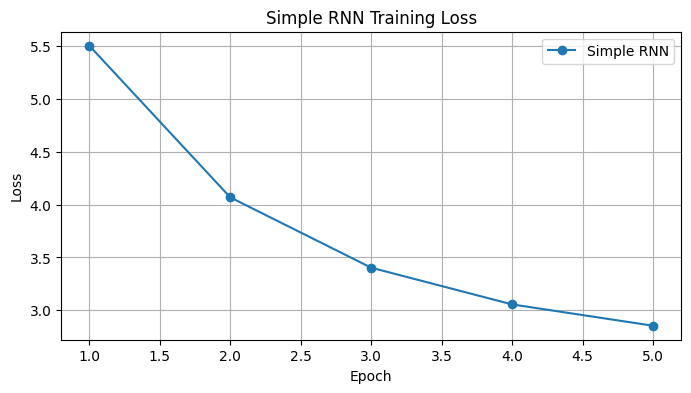

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), rnn_losses, marker="o", label="Simple RNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Simple RNN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

phase 3 --LSTM

In [ ]:
class LSTMModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc        = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x           = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out         = self.fc(out)
        return out, hidden

In [ ]:
lstm_model = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM).to(device)
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=LR)

In [ ]:
print(f"parameters : {sum(p.numel() for p in lstm_model.parameters()):,}")


parameters : 2,029,714


In [ ]:
lstm_losses = []
start_time  = time.time()
for epoch in range(EPOCHS):
    lstm_model.train()
    total_loss = 0
    for batch_inputs, batch_targets in dataloader:
        batch_inputs  = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)
        optimizer.zero_grad()
        output, _  = lstm_model(batch_inputs)
        loss       = criterion(
            output.view(-1, VOCAB_SIZE),
            batch_targets.view(-1)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    lstm_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")
elapsed = time.time() - start_time
print(f"\ntraining using lstm completed")
print(f"Time taken : {elapsed/60:.2f} minutes")

Epoch 1/5 - Loss: 5.7584
Epoch 2/5 - Loss: 4.7126
Epoch 3/5 - Loss: 4.1328
Epoch 4/5 - Loss: 3.7101
Epoch 5/5 - Loss: 3.3867

training using lstm completed
Time taken : 2.49 minutes


In [ ]:
def generate_text_lstm(model, start_word, word2idx, idx2word, max_words=50, temperature=0.8):
    model.eval()

    input_idx = torch.tensor([[word2idx.get(start_word, 1)]]).to(device)
    hidden    = None
    words     = [start_word]

    with torch.no_grad():
        for _ in range(max_words):
            output, hidden = model(input_idx, hidden)
            logits         = output[0, -1] / temperature
            probabilities  = torch.softmax(logits, dim=0)
            next_idx       = torch.multinomial(probabilities, 1).item()
            next_word      = idx2word.get(next_idx, "<UNK>")
            words.append(next_word)
            input_idx      = torch.tensor([[next_idx]]).to(device)

    return " ".join(words)

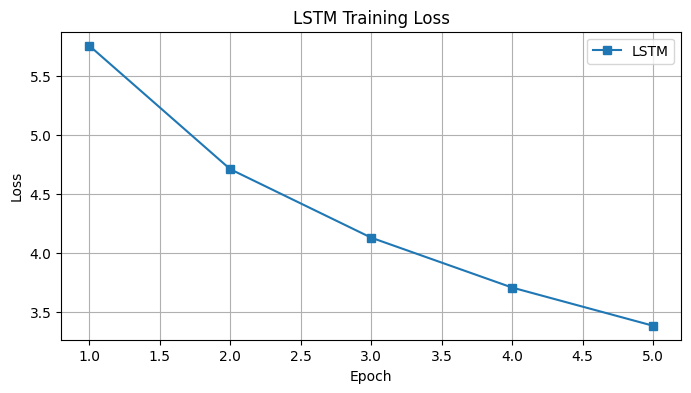

In [ ]:
plt.figure(figsize=(8, 4))
# plt.plot(range(1, EPOCHS+1), rnn_losses,  marker="o", label="Simple RNN")
plt.plot(range(1, EPOCHS+1), lstm_losses, marker="s", label="LSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training Loss")
plt.legend()
plt.grid(True)
plt.show()

training using transformer

In [ ]:
class SelfAttention(nn.Module):

    def __init__(self, embed_dim, num_heads):
        super(SelfAttention, self).__init__()

        self.num_heads  = num_heads
        self.head_dim   = embed_dim // num_heads

        self.query      = nn.Linear(embed_dim, embed_dim)
        self.key        = nn.Linear(embed_dim, embed_dim)
        self.value      = nn.Linear(embed_dim, embed_dim)
        self.fc         = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        batch, seq_len, embed_dim = x.shape

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        Q = Q.view(batch, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores     = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attention  = torch.softmax(scores, dim=-1)
        out        = torch.matmul(attention, V)

        out = out.transpose(1, 2).contiguous().view(batch, seq_len, embed_dim)
        out = self.fc(out)

        return out, attention

In [ ]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):

    def __init__(self, embed_dim, max_len=5000):
        super(PositionalEncoding, self).__init__()

        pe       = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [ ]:
class TransformerBlock(nn.Module):

    def __init__(self, embed_dim, num_heads, hidden_dim, dropout=0.1):
        super(TransformerBlock, self).__init__()

        self.attention  = SelfAttention(embed_dim, num_heads)
        self.norm1      = nn.LayerNorm(embed_dim)
        self.norm2      = nn.LayerNorm(embed_dim)
        self.ff         = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim)
        )
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attention = self.attention(x)
        x   = self.norm1(x + self.dropout(attn_out))
        ff  = self.ff(x)
        x   = self.norm2(x + self.dropout(ff))
        return x, attention

In [ ]:
class TransformerModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, hidden_dim, dropout=0.1):
        super(TransformerModel, self).__init__()

        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_enc    = PositionalEncoding(embed_dim)
        self.layers     = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, hidden_dim, dropout)
            for _ in range(num_layers)
        ])
        self.fc         = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        x           = self.embedding(x)
        x           = self.pos_enc(x)
        attentions  = []
        for layer in self.layers:
            x, attention = layer(x)
            attentions.append(attention)
        out = self.fc(x)
        return out, attentions

In [ ]:
EMBED_DIM  = 64
NUM_HEADS  = 2
NUM_LAYERS = 2
HIDDEN_DIM = 128
DROPOUT    = 0.3
EPOCHS     = 10
LR         = 0.001

transformer_model = TransformerModel(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    hidden_dim  = HIDDEN_DIM,
    dropout     = DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(transformer_model.parameters(), lr=LR , weight_decay=1e-4)






In [ ]:
NUM_HEADS


4

In [ ]:
NUM_LAYERS

3

In [ ]:
print(f"Parameters : {sum(p.numel() for p in transformer_model.parameters()):,}")

Parameters : 2,967,954


In [ ]:
EPOCHS = 20


torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)

tensor(0.)

In [ ]:
transformer_losses = []
start_time         = time.time()

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

for epoch in range(EPOCHS):
    transformer_model.train()
    total_loss = 0

    for batch_inputs, batch_targets in dataloader:
        batch_inputs  = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        optimizer.zero_grad()
        output, _  = transformer_model(batch_inputs)
        loss       = criterion(
            output.view(-1, VOCAB_SIZE),
            batch_targets.view(-1)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    transformer_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")

elapsed = time.time() - start_time
print(f"\nTransformer Training Complete")
print(f"Time taken : {elapsed/60:.2f} minutes")

Epoch 1/10 - Loss: 3.1401
Epoch 2/10 - Loss: 1.6568
Epoch 3/10 - Loss: 1.6056
Epoch 4/10 - Loss: 1.5860
Epoch 5/10 - Loss: 1.5765
Epoch 6/10 - Loss: 1.5710
Epoch 7/10 - Loss: 1.5676
Epoch 8/10 - Loss: 1.5650
Epoch 9/10 - Loss: 1.5632
Epoch 10/10 - Loss: 1.5616

Transformer Training Complete
Time taken : 5.13 minutes


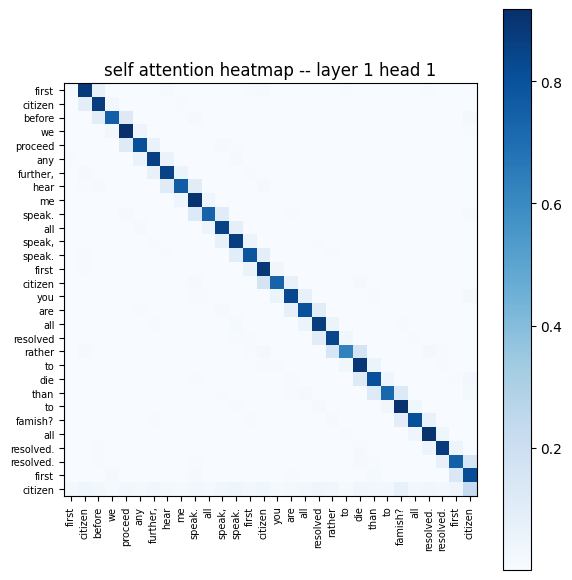

In [ ]:
transformer_model.eval()

sample_input  = inputs[0].unsqueeze(0).to(device)
sample_words  = [idx2word.get(i.item(), "<UNK>") for i in inputs[0]]

with torch.no_grad():
    _, attentions = transformer_model(sample_input)

attn_map = attentions[0][0, 0].cpu().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(attn_map, cmap="Blues")
plt.xticks(range(len(sample_words)), sample_words, rotation=90, fontsize=7)
plt.yticks(range(len(sample_words)), sample_words, fontsize=7)
plt.title("self attention heatmap -- layer 1 head 1")
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
def generate_text_transformer(model, start_word, word2idx, idx2word, max_words=50, temperature=1.2, top_k=50):
    model.eval()

    words     = [start_word]
    input_idx = [word2idx.get(start_word, 1)]

    with torch.no_grad():
        for _ in range(max_words):
            input_tensor  = torch.tensor(

              [input_idx]).to(device)
            output, _     = model(input_tensor)

            logits        = output[0, -1] / temperature

            # Top-K sampling — only consider top k words
            top_k_logits, top_k_indices = torch.topk(logits, top_k)
            probabilities = torch.softmax(top_k_logits, dim=0)
            sampled       = torch.multinomial(probabilities, 1).item()
            next_idx      = top_k_indices[sampled].item()

            next_word     = idx2word.get(next_idx, "<UNK>")
            words.append(next_word)
            input_idx.append(next_idx)

    return " ".join(words)

print("Generated Text — Transformer")
print("-" * 50)
print(generate_text_transformer(transformer_model, "the",  word2idx, idx2word,temperature=1.5,top_k=50))
print()
print(generate_text_transformer(transformer_model, "king", word2idx, idx2word,temperature=1.5,top_k=50))
print()
print(generate_text_transformer(transformer_model, "war",  word2idx, idx2word,temperature=1.5,top_k=50))

Generated Text — Transformer
--------------------------------------------------
the the the the of of of of of of of of of of of of of of of of of of of brought brought brought brought brought brought brought of of in which she then go but of and but you like speak to some must unto there for where

king king king king king king king king king king king king king king king king king king king king king king king king king king king king king king king king king pardon tranio for grace you king constant but for you but you post you you found him king

war war war war war war war war war war war war war war war war war one one one one one one one one one one one one one war one one one lay but what servingman one servant head and where sorrow. one iv it, and some then cousin,


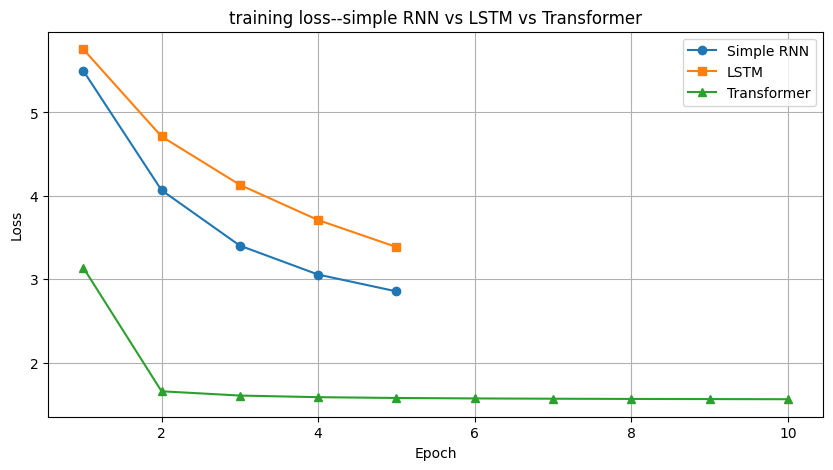

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot lines
plt.plot(range(1, len(rnn_losses)+1),
         rnn_losses,
         marker="o",
         linewidth=2,
         label="Simple RNN")

plt.plot(range(1, len(lstm_losses)+1),
         lstm_losses,
         marker="s",
         linewidth=2,
         label="LSTM")

plt.plot(range(1, len(transformer_losses)+1),
         transformer_losses,
         marker="^",
         linewidth=2,
         label="Transformer")

# Labels
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

# Title
plt.title("Training Loss Comparison: RNN vs LSTM vs Transformer",
          fontsize=14,
          fontweight='bold')

# Legend
plt.legend(fontsize=11)

# Grid
plt.grid(alpha=0.3)

# ✅ Insight inside plot (clean + no overlap ever)
plt.text(2, 2.2,
         "LSTM performs best on small data\nTransformers need scale",
         fontsize=10,
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [ ]:
start_words = ["the", "king", "war"]

for word in start_words:

    print(f"Start word: {word}")

    print("Simple RNN:")
    print(generate_text(model, word, word2idx, idx2word, temperature=0.8))

    print("\nLSTM:")

    print(generate_text_lstm(lstm_model, word, word2idx, idx2word, temperature=0.8))

    print("\nTransformer:")
    print(generate_text_transformer(transformer_model, word, word2idx, idx2word, temperature=1.5, top_k=50))
    print()

Start word: the
Simple RNN:
the heads of <UNK> which fondly they view his ears he had, that must be resolved with a man that bears the <UNK> king <UNK> i say you shall. buckingham must hast we will. first citizen i am too fond, and not bewray you of much than a part of a

LSTM:
the hand that babies <UNK> <UNK> and <UNK> for thanks i doubt not now the mayor what is no earthly of you are doing in the <UNK> of their <UNK> like a careful man that you <UNK> petruchio why, what then? so would you stand for i pray thee? romeo as

Transformer:
the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the and and and the the what there and and the the than and and some here the

Start word: king
Simple RNN:
king henry vi so <UNK> king richard iii <UNK> i thank him. isabella alas, your saint george, beloved therefore, let him approach be <UNK> in this paper here. henry bolingbroke my lord, we would have heard the sea and <

In [ ]:
print("=" * 60)
print("FINAL COMPARISON SUMMARY")
print("=" * 60)

print(f"\nSimple RNN")
print(f"  Final Loss    : {rnn_losses[-1]:.4f}")
print(f"  Parameters    : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Text Quality  : Basic — loses context quickly")

print(f"\nLSTM")
print(f"  Final Loss    : {lstm_losses[-1]:.4f}")
print(f"  Parameters    : {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"  Text Quality  : Better — remembers longer context")

print(f"\nTransformer")
print(f"  Final Loss    : {transformer_losses[-1]:.4f}")
print(f"  Parameters    : {sum(p.numel() for p in transformer_model.parameters()):,}")
print(f"  Text Quality  : Needs more data and compute to shine")

print("\nKey Insight:")
print("Transformers outperform RNN and LSTM at scale")
print("On small datasets RNNs can actually perform better")
print("This is why GPT uses massive datasets and compute")

FINAL COMPARISON SUMMARY

Simple RNN
  Final Loss    : 2.8549
  Parameters    : 1,955,218
  Text Quality  : Basic — loses context quickly

LSTM
  Final Loss    : 3.3867
  Parameters    : 2,029,714
  Text Quality  : Better — remembers longer context

Transformer
  Final Loss    : 1.5616
  Parameters    : 1,357,202
  Text Quality  : Needs more data and compute to shine

Key Insight:
Transformers outperform RNN and LSTM at scale
On small datasets RNNs can actually perform better
This is why GPT uses massive datasets and compute
